# Fundamentals of Machine Learning — Exercise 4

## Hierarchical Clustering, DBSCAN, and Choosing a Clustering Method

In Exercise 3, K-means showed us that clustering depends on representation, distance, scaling, and the chosen number of clusters.

This exercise asks a new question:

> **What should we do when clusters are not compact, spherical groups around a centroid?**

We will compare:

- **K-means**,
- **agglomerative hierarchical clustering**,
- **DBSCAN**.

The classroom workflow remains:

> **question → prediction → computation → visualisation → interpretation → verification**

### Learning outcomes

After completing this exercise, you should be able to:

- explain the bottom-up idea of agglomerative clustering,
- read a dendrogram and explain what a horizontal cut represents,
- distinguish single, complete, and Ward linkage,
- explain the roles of `eps` and `min_samples` in DBSCAN,
- identify core points, border points, and noise,
- compare clustering methods according to data geometry and noise,
- recognise that one numerical metric cannot decide every clustering problem,
- justify a clustering method using several pieces of evidence,
- use an AI chatbot to question a decision after forming your own answer.

**Recommended duration:** 100–120 minutes.  
The final method-selection memo may be completed as homework.

## How to work in this exercise

Most code is already prepared. Your task is to:

1. **predict** the result before running a cell,
2. **change** only clearly marked settings,
3. **compare** alternative methods,
4. **interpret** the output using numerical and visual evidence,
5. **verify** an important claim with a second piece of evidence.

Do not choose a method only because its plot “looks nice”.  
A defensible conclusion should mention:

- the expected cluster shape,
- the role of distance or density,
- sensitivity to noise,
- at least one numerical result,
- one limitation.

## 0. Imports

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.datasets import make_blobs, make_moons, make_circles, load_wine
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 12

## 1. The same number of groups can have different geometry

We begin with three artificial datasets. Each dataset contains **two known generating groups**, but the shapes are different.

Before running the cell, predict which dataset should be easiest for K-means.

| Dataset | Expected shape | Will K-means work well? Why? |
|---|---|---|
| Compact blobs | small spheres | yes, easy to find centroid |
| Two moons | two crescent shapes | no |
| Concentric circles | two circles, one smaller inside the other | no |

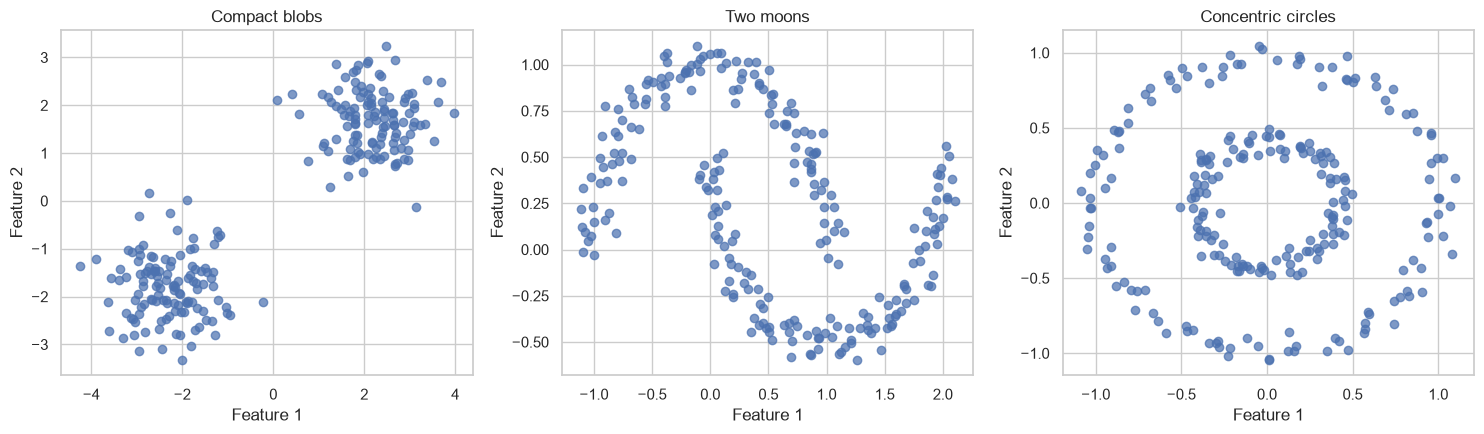

In [6]:
X_blobs, y_blobs = make_blobs(
    n_samples=240,
    centers=[(-2.2, -1.7), (2.2, 1.7)],
    cluster_std=[0.65, 0.70],
    random_state=RANDOM_STATE,
)

X_moons, y_moons = make_moons(
    n_samples=240,
    noise=0.07,
    random_state=RANDOM_STATE,
)

X_circles, y_circles = make_circles(
    n_samples=240,
    factor=0.42,
    noise=0.05,
    random_state=RANDOM_STATE,
)

toy_sets = {
    "Compact blobs": (X_blobs, y_blobs),
    "Two moons": (X_moons, y_moons),
    "Concentric circles": (X_circles, y_circles),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for axis, (name, (X, _)) in zip(axes, toy_sets.items()):
    axis.scatter(X[:, 0], X[:, 1], alpha=0.72)
    axis.set_title(name)
    axis.set_xlabel("Feature 1")
    axis.set_ylabel("Feature 2")

plt.tight_layout()
plt.show()

### Run the same K-means model on all three datasets

The value `k=2` is deliberately kept constant. The question is not whether we supplied the correct number of clusters, but whether the **model assumption** fits the geometry.

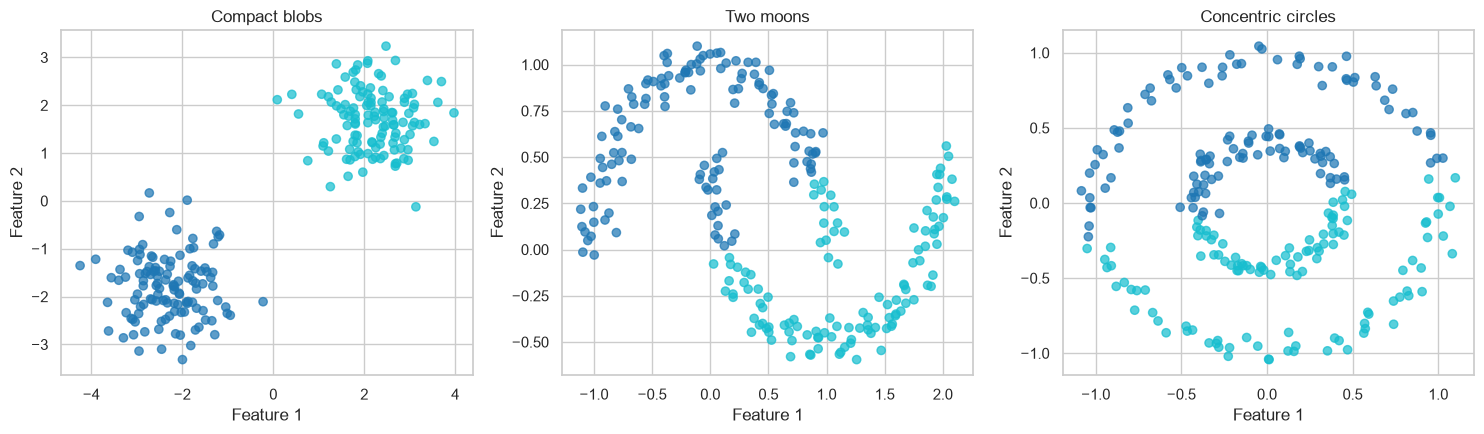

,labels,ARI against generating groups,silhouette
Compact blobs,"[0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, ...",1.0,0.785946
Two moons,"[0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, ...",0.487863,0.491559
Concentric circles,"[0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, ...",-0.003922,0.338079


In [4]:
kmeans_results = {}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for axis, (name, (X, true_group)) in zip(axes, toy_sets.items()):
    X_scaled = StandardScaler().fit_transform(X)

    labels = KMeans(
        n_clusters=2,
        n_init=20,
        random_state=42,
    ).fit_predict(X_scaled)

    kmeans_results[name] = {
        "labels": labels,
        "ARI against generating groups": adjusted_rand_score(true_group, labels),
        "silhouette": silhouette_score(X_scaled, labels),
    }

    axis.scatter(X[:, 0], X[:, 1], c=labels, cmap="tab10", alpha=0.72)
    axis.set_title(name)
    axis.set_xlabel("Feature 1")
    axis.set_ylabel("Feature 2")

plt.tight_layout()
plt.show()

pd.DataFrame(kmeans_results).T.round(3)

### Activity 1 — Explain a failure, not only a score

Complete the argument:

> K-means performs well on _____Compact blobs_____ because _____they are compact, round, and well separated, so each group has an obvious centre_____.
>
> K-means fails on _____Two moons and Concentric circles_____ even though `k=2`, because _____of their complex shape that cannot be separated by a straight linear boundary_____.
>
> The failure is caused mainly by the method's assumption that _____clusters are spherical_____.

Why is “the algorithm found two clusters” insufficient evidence that the partition is meaningful?

**Answer:** K-means always returns exactly k groups, whatever the data look like. On the moons it gave ARI = 0.488 and on the circles ARI = −0.004 (no better than random), even though it still reported two tidy clusters. The partition is only meaningful if it matches the real structure, so we need to check the shape visually and with an independent score, not just count clusters.

## 2. Agglomerative clustering: building a hierarchy of merges

Agglomerative clustering is a **bottom-up** procedure:

1. each observation starts as its own cluster,
2. the closest pair of clusters is merged,
3. distances between the new clusters are recomputed,
4. merging continues until only one cluster remains.

A dendrogram records this process.

- Leaves at the bottom represent observations.
- A horizontal connection represents a merge.
- The height of a merge represents the dissimilarity at which it occurred.
- A horizontal cut converts the hierarchy into a chosen partition.

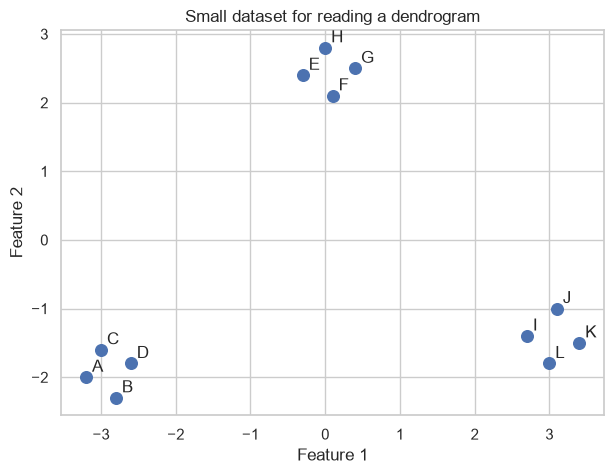

In [5]:
X_small = np.array([
    [-3.2, -2.0], [-2.8, -2.3], [-3.0, -1.6], [-2.6, -1.8],
    [-0.3,  2.4], [ 0.1,  2.1], [ 0.4,  2.5], [ 0.0,  2.8],
    [ 2.7, -1.4], [ 3.1, -1.0], [ 3.4, -1.5], [ 3.0, -1.8],
])
point_names = list("ABCDEFGHIJKL")

plt.figure(figsize=(7, 5))
plt.scatter(X_small[:, 0], X_small[:, 1], s=70)

for name, (x, y) in zip(point_names, X_small):
    plt.text(x + 0.08, y + 0.08, name)

plt.title("Small dataset for reading a dendrogram")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

### Predict before viewing the dendrogram

1. Which points do you expect to merge first? - The 4 points that are in a group together, forming 3 groups
2. Which three broad groups do you see? - A, B, C, D/ E, F, G, H/ I, J, K, L
3. At approximately what stage should the algorithm begin merging genuinely different groups? - Once all the small groups are merged together

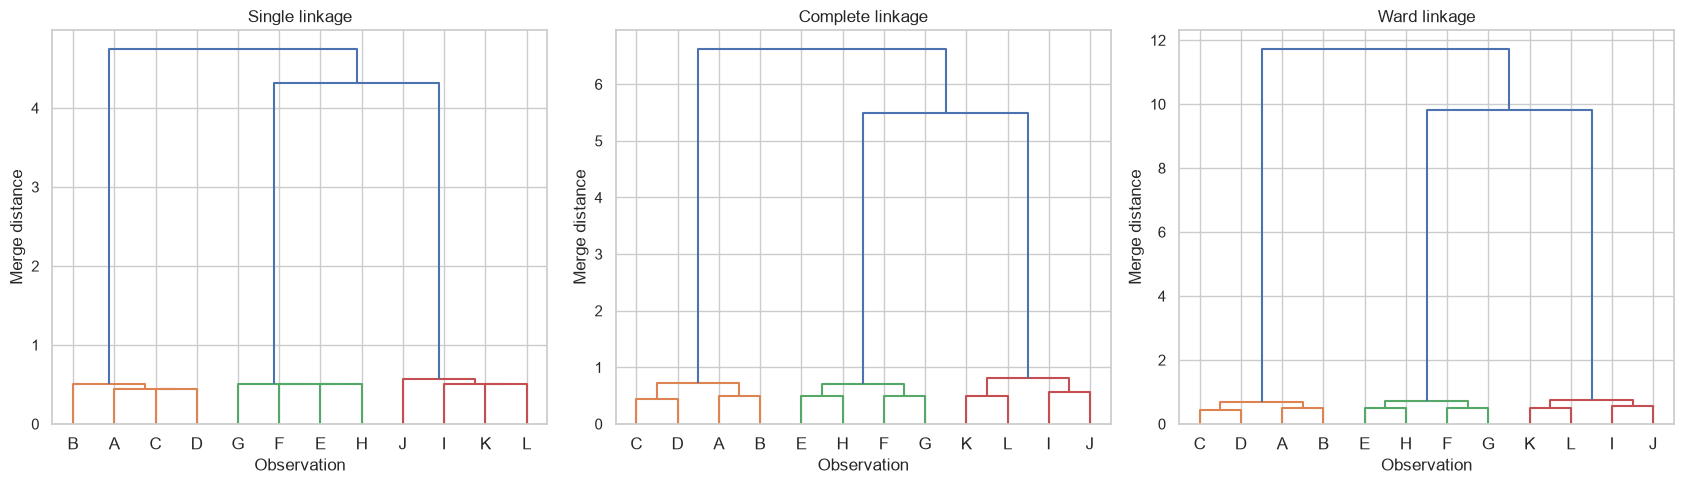

In [7]:
linkage_methods = ["single", "complete", "ward"]
small_linkages = {
    method: linkage(X_small, method=method)
    for method in linkage_methods
}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for axis, method in zip(axes, linkage_methods):
    dendrogram(
        small_linkages[method],
        labels=point_names,
        ax=axis,
    )
    axis.set_title(f"{method.capitalize()} linkage")
    axis.set_xlabel("Observation")
    axis.set_ylabel("Merge distance")

plt.tight_layout()
plt.show()

### Activity 2 — Read the hierarchy

Choose one dendrogram and answer: Ward linkage

1. Name one pair of observations that merges early. - C and D
2. Identify one large vertical gap. - once the small groups merge around 1.0, there is a gap until around 9.5 where the groups are forced to merge together
3. What number of clusters would a cut inside that gap produce? - 3 merged at around 1.0
4. Why can the answer differ between linkage methods? - Because each method evaluates cluster proximity differently

Do not write only “three clusters are visible”. Point to a merge height or a gap.

### Change the cut, not the hierarchy

The complete hierarchy remains fixed. We now choose a horizontal cut.

Change only `CUT_HEIGHT` and observe the number of clusters.

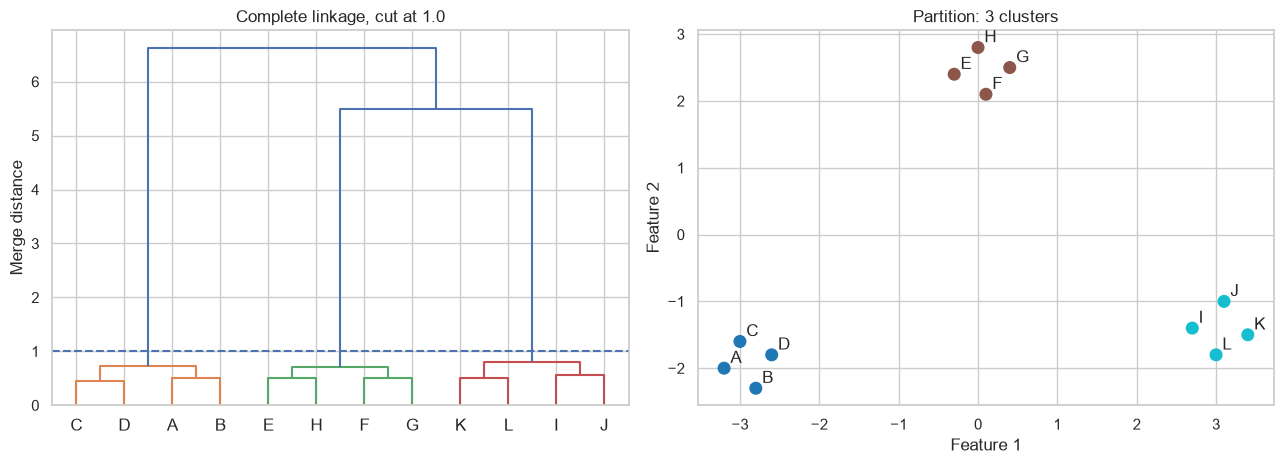

In [15]:
CUT_HEIGHT = 1.0

complete_labels = fcluster(
    small_linkages["complete"],
    t=CUT_HEIGHT,
    criterion="distance",
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

dendrogram(
    small_linkages["complete"],
    labels=point_names,
    ax=axes[0],
)
axes[0].axhline(CUT_HEIGHT, linestyle="--")
axes[0].set_title(f"Complete linkage, cut at {CUT_HEIGHT}")
axes[0].set_ylabel("Merge distance")

axes[1].scatter(
    X_small[:, 0],
    X_small[:, 1],
    c=complete_labels,
    cmap="tab10",
    s=70,
)
for name, (x, y) in zip(point_names, X_small):
    axes[1].text(x + 0.08, y + 0.08, name)
axes[1].set_title(
    f"Partition: {pd.Series(complete_labels).nunique()} clusters"
)
axes[1].set_xlabel("Feature 1")
axes[1].set_ylabel("Feature 2")

plt.tight_layout()
plt.show()

### Stop and explain

Complete the sentences:

> Moving the cut **upward** usually produces _____less_____ clusters because _____once you reach a certain threshold the algorithm merges the small clusters together_____.
>
> Moving the cut **downward** usually produces _____more_____ clusters because _____the elements don't have enough "time" to merge_____.
>
> Choosing a cut is still a modelling decision because _____it decides the number of clusters and what points get clustered together_____.

## 3. Linkage changes what “closest clusters” means

We compare three common choices:

- **Single linkage:** distance between the closest pair of points from two clusters.
- **Complete linkage:** distance between the farthest pair of points.
- **Ward linkage:** merges clusters that cause the smallest increase in within-cluster variance.

Before running the next cell, predict which linkage is most likely to follow the curved moons. - Single linkage

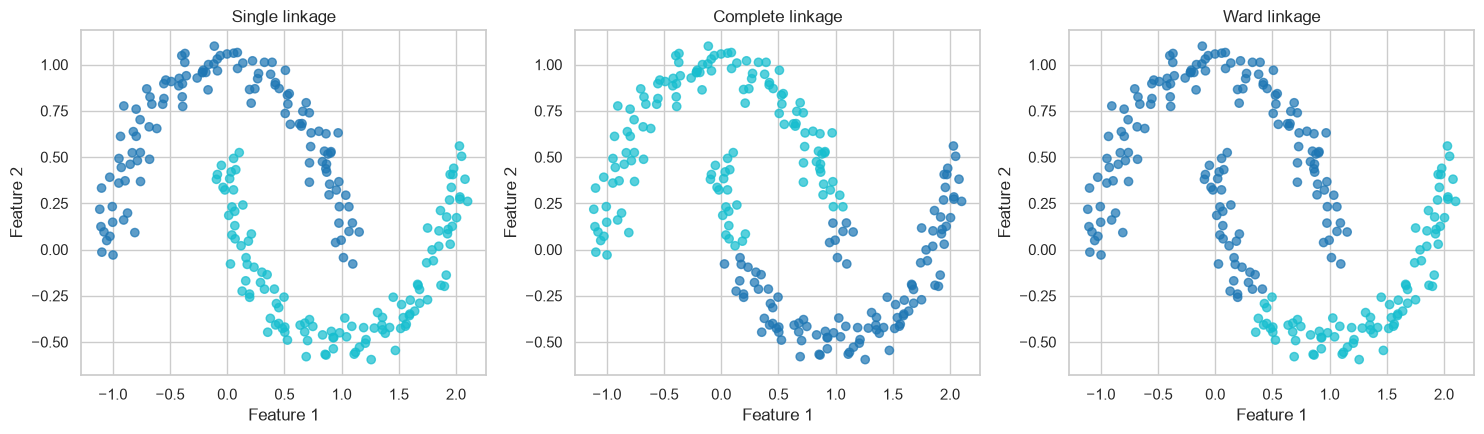

,silhouette,ARI against generating groups
single,0.370,1.000
complete,0.484,0.573
ward,0.441,0.512


In [16]:
X_moons_scaled = StandardScaler().fit_transform(X_moons)

moon_linkage_results = {}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for axis, method in zip(axes, linkage_methods):
    labels = AgglomerativeClustering(
        n_clusters=2,
        linkage=method,
    ).fit_predict(X_moons_scaled)

    moon_linkage_results[method] = {
        "silhouette": silhouette_score(X_moons_scaled, labels),
        "ARI against generating groups": adjusted_rand_score(y_moons, labels),
    }

    axis.scatter(
        X_moons[:, 0],
        X_moons[:, 1],
        c=labels,
        cmap="tab10",
        alpha=0.72,
    )
    axis.set_title(f"{method.capitalize()} linkage")
    axis.set_xlabel("Feature 1")
    axis.set_ylabel("Feature 2")

plt.tight_layout()
plt.show()

pd.DataFrame(moon_linkage_results).T.round(3)

### Activity 3 — Link the result to the definition

1. Which linkage best follows the two moons? - Single linkage
2. Explain the result using the definition of that linkage. - it takes the distance between the closest pair of points, so it doesn't "jump" across to the other moon
3. Which method creates more compact groups? - Complete and Ward linkage
4. What risk might arise if a few points form a thin “bridge” between two groups? - it might merge the two independent groups

## 4. DBSCAN: clusters as dense regions

DBSCAN uses two main parameters:

- `eps`: the radius of a neighbourhood,
- `min_samples`: the minimum number of nearby observations needed for a dense region.

It distinguishes:

- **core points** — sufficiently dense neighbourhood,
- **border points** — near a core point but not dense enough themselves,
- **noise** — points that do not belong to a dense region.

DBSCAN does **not** require the number of clusters in advance.  
However, it does require a defensible density scale.

### Predict the effect of `eps`

Keep `min_samples=5`.

| `eps` | Your prediction |
|---:|---|
| 0.10 | It will fragment into multiple different clusters |
| 0.18 | Ideal value to create two separate clusters for each crescent moon with minimal to no noise |
| 0.32 | It will merge both moons into one cluster |

Use the words **fragment**, **noise**, or **merge** where appropriate.

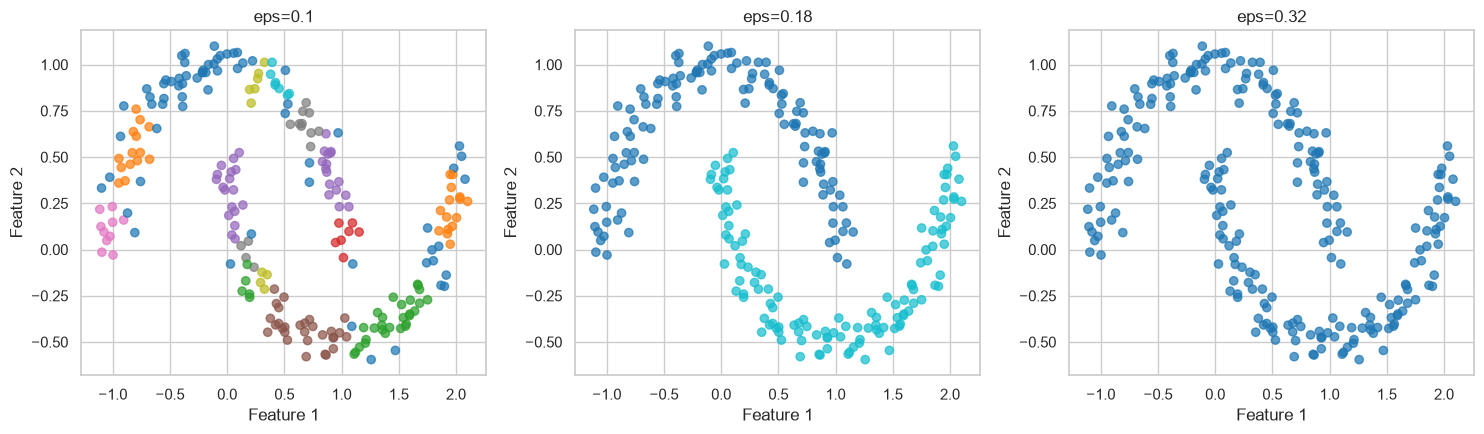

,eps,clusters excluding noise,noise points,silhouette excluding noise,ARI against generating groups
0,0.10,17,38,0.461,0.113
1,0.18,2,0,0.317,1.000
2,0.32,1,0,NaN,0.000


In [18]:
EPS_VALUES = [0.10, 0.18, 0.32]
dbscan_rows = []

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for axis, eps in zip(axes, EPS_VALUES):
    labels = DBSCAN(
        eps=eps,
        min_samples=5,
    ).fit_predict(X_moons)

    non_noise = labels != -1
    n_clusters = len(set(labels[non_noise]))

    if n_clusters >= 2 and non_noise.sum() > n_clusters:
        silhouette = silhouette_score(
            X_moons[non_noise],
            labels[non_noise],
        )
    else:
        silhouette = np.nan

    dbscan_rows.append({
        "eps": eps,
        "clusters excluding noise": n_clusters,
        "noise points": int((labels == -1).sum()),
        "silhouette excluding noise": silhouette,
        "ARI against generating groups": adjusted_rand_score(y_moons, labels),
    })

    axis.scatter(
        X_moons[:, 0],
        X_moons[:, 1],
        c=labels,
        cmap="tab10",
        alpha=0.72,
    )
    axis.set_title(f"eps={eps}")
    axis.set_xlabel("Feature 1")
    axis.set_ylabel("Feature 2")

plt.tight_layout()
plt.show()

pd.DataFrame(dbscan_rows).round(3)

### Activity 4 — Explain parameter sensitivity

For each value of `eps`, describe what happened.

**What happened (min_samples=5, from the table above):**

- `eps=0.10` — the radius is too small, so the moons **fragment** into 17 small clusters and 38 points become **noise** (ARI = 0.113).
- `eps=0.18` — 2 clusters, 0 noise points, ARI = 1.000: each moon is recovered exactly.
- `eps=0.32` — the radius bridges the gap between the moons, so they **merge** into 1 cluster (ARI = 0.000).

Then complete:

> A very small `eps` can create many small clusters or noise because _____the neighbourhood radius is too low and separates even the smallest gaps_____.
>
> A very large `eps` can merge distinct groups because _____the neighbourhood radius is too high and expands beyond small gaps_____.
>
> Therefore, DBSCAN does not remove parameter choice; it changes the question from “how many clusters?” to _____"what local density radius defines a meaningful cluster?"_____.

### A nearest-neighbour distance plot as a diagnostic

For `min_samples=5`, we inspect each observation's distance to its fifth nearest neighbour.

A bend in this sorted curve can suggest an `eps` candidate. It is **not an automatic answer**.

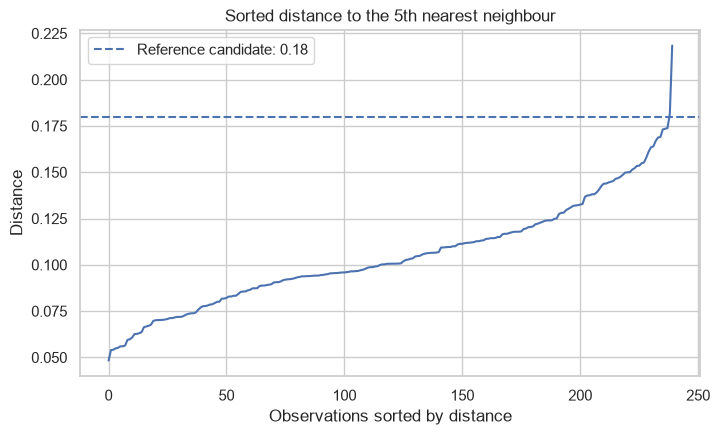

In [19]:
MIN_SAMPLES = 5

neighbours = NearestNeighbors(n_neighbors=MIN_SAMPLES)
neighbour_distances, _ = neighbours.fit(X_moons).kneighbors(X_moons)

fifth_neighbour_distance = np.sort(
    neighbour_distances[:, -1]
)

plt.figure(figsize=(8, 4.5))
plt.plot(fifth_neighbour_distance)
plt.axhline(0.18, linestyle="--", label="Reference candidate: 0.18")
plt.title("Sorted distance to the 5th nearest neighbour")
plt.xlabel("Observations sorted by distance")
plt.ylabel("Distance")
plt.legend()
plt.show()

### Verification checkpoint

Does the distance plot support considering `eps≈0.18`? - Yes it does

Answer cautiously:

- What pattern do you see? - A long almost linear rise that turns into a sharp rising spike at the end after around 200 observations
- Is there one perfectly sharp elbow? - No
- Why should you still inspect the resulting partition? - because other values could also solve the shape

### Core, border, and noise points

We now inspect the selected DBSCAN solution directly.

core      238
border      2
Name: count, dtype: int64

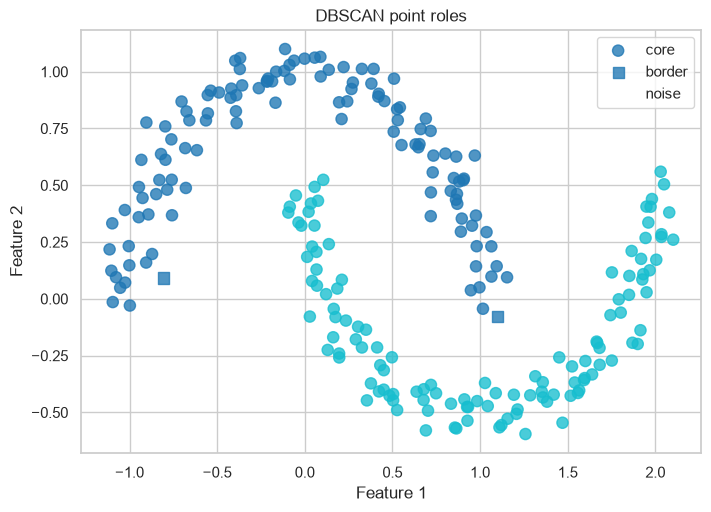

In [21]:
selected_dbscan = DBSCAN(
    eps=0.18,
    min_samples=5,
).fit(X_moons)

selected_labels = selected_dbscan.labels_

core_mask = np.zeros(len(X_moons), dtype=bool)
core_mask[selected_dbscan.core_sample_indices_] = True

point_role = np.full(len(X_moons), "border", dtype=object)
point_role[core_mask] = "core"
point_role[selected_labels == -1] = "noise"

role_counts = pd.Series(point_role).value_counts()
display(role_counts)

plt.figure(figsize=(8, 5.5))

for role, marker in [("core", "o"), ("border", "s"), ("noise", "x")]:
    mask = point_role == role
    plt.scatter(
        X_moons[mask, 0],
        X_moons[mask, 1],
        c=selected_labels[mask],
        cmap="tab10",
        marker=marker,
        s=65,
        alpha=0.78,
        label=role,
    )

plt.title("DBSCAN point roles")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

### Stop and explain

Why is a border point allowed to belong to a cluster even though its own neighbourhood is not dense enough? - It falls within a neighbourhood radius of a point that is a part of a cluster

Why is the label `-1` different from an ordinary cluster number? - Special indicator for noise

## 5. Compare methods systematically

We now apply several methods to all three geometries.

For this controlled experiment:

- each dataset is standardised,
- methods that require a cluster count receive `2`,
- DBSCAN uses `eps=0.40` and `min_samples=5`,
- the generating groups are used only as an **external audit**.

In [22]:
def count_clusters(labels):
    labels = np.asarray(labels)
    return len(set(labels[labels != -1]))

def silhouette_without_noise(X, labels):
    labels = np.asarray(labels)
    mask = labels != -1
    n_clusters = count_clusters(labels)

    if n_clusters < 2 or mask.sum() <= n_clusters:
        return np.nan

    return silhouette_score(X[mask], labels[mask])

comparison_rows = []
comparison_labels = {}

for dataset_name, (X, true_group) in toy_sets.items():
    X_scaled = StandardScaler().fit_transform(X)

    methods = {
        "K-means": KMeans(
            n_clusters=2,
            n_init=20,
            random_state=42,
        ).fit_predict(X_scaled),

        "Agglomerative — single": AgglomerativeClustering(
            n_clusters=2,
            linkage="single",
        ).fit_predict(X_scaled),

        "Agglomerative — complete": AgglomerativeClustering(
            n_clusters=2,
            linkage="complete",
        ).fit_predict(X_scaled),

        "Agglomerative — Ward": AgglomerativeClustering(
            n_clusters=2,
            linkage="ward",
        ).fit_predict(X_scaled),

        "DBSCAN": DBSCAN(
            eps=0.40,
            min_samples=5,
        ).fit_predict(X_scaled),
    }

    for method_name, labels in methods.items():
        comparison_labels[(dataset_name, method_name)] = labels

        comparison_rows.append({
            "dataset": dataset_name,
            "method": method_name,
            "clusters": count_clusters(labels),
            "noise points": int((labels == -1).sum()),
            "silhouette": silhouette_without_noise(X_scaled, labels),
            "ARI against generating groups": adjusted_rand_score(
                true_group,
                labels,
            ),
        })

comparison_table = pd.DataFrame(comparison_rows)
comparison_table.round(3)

,dataset,method,clusters,noise points,silhouette,ARI against generating groups
0,Compact blobs,K-means,2,0,0.786,1.000
1,Compact blobs,Agglomerative — single,2,0,0.786,1.000
2,Compact blobs,Agglomerative — complete,2,0,0.786,1.000
3,Compact blobs,Agglomerative — Ward,2,0,0.786,1.000
4,Compact blobs,DBSCAN,2,1,0.788,0.992
5,Two moons,K-means,2,0,0.492,0.488
6,Two moons,Agglomerative — single,2,0,0.370,1.000
7,Two moons,Agglomerative — complete,2,0,0.484,0.573
8,Two moons,Agglomerative — Ward,2,0,0.441,0.512
9,Two moons,DBSCAN,2,0,0.370,1.000


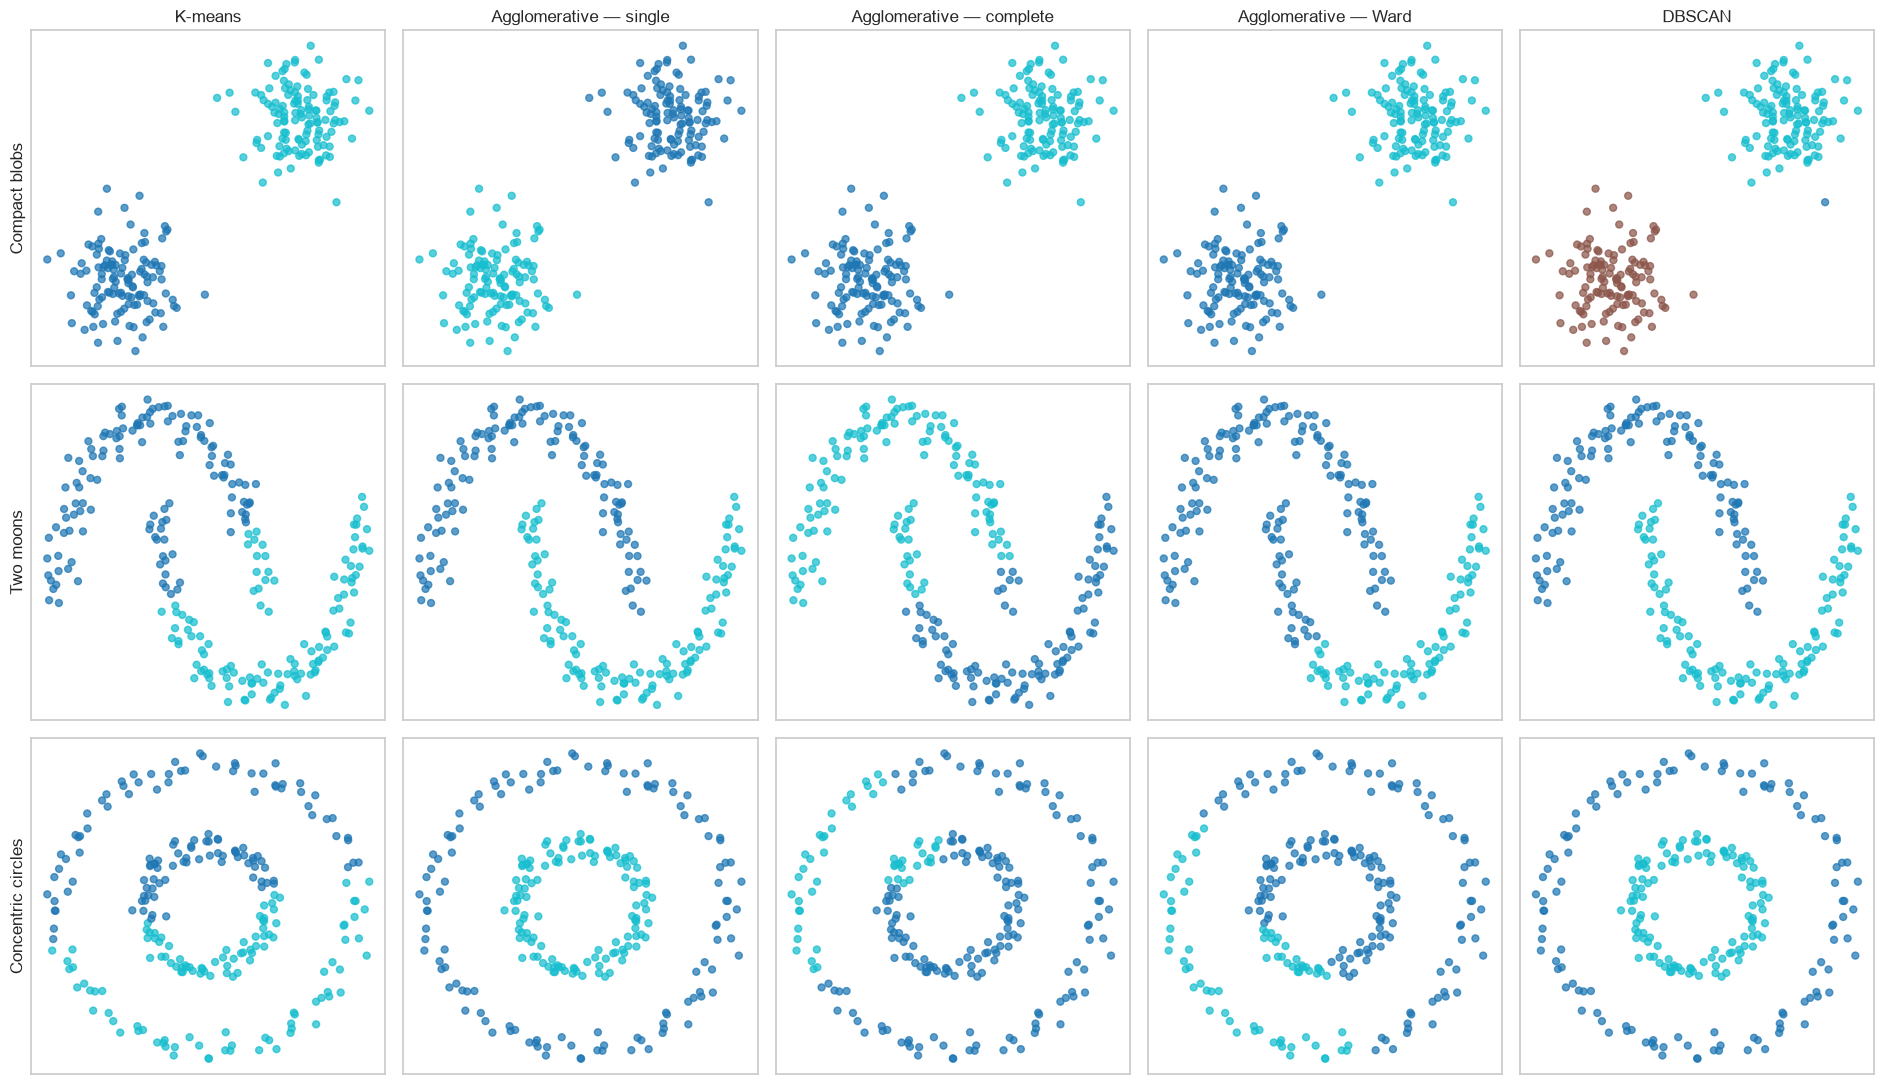

In [23]:
method_order = [
    "K-means",
    "Agglomerative — single",
    "Agglomerative — complete",
    "Agglomerative — Ward",
    "DBSCAN",
]

fig, axes = plt.subplots(
    len(toy_sets),
    len(method_order),
    figsize=(19, 11),
)

for row_index, (dataset_name, (X, _)) in enumerate(toy_sets.items()):
    for column_index, method_name in enumerate(method_order):
        axis = axes[row_index, column_index]
        labels = comparison_labels[(dataset_name, method_name)]

        axis.scatter(
            X[:, 0],
            X[:, 1],
            c=labels,
            cmap="tab10",
            s=25,
            alpha=0.72,
        )

        if row_index == 0:
            axis.set_title(method_name)

        if column_index == 0:
            axis.set_ylabel(dataset_name)

        axis.set_xticks([])
        axis.set_yticks([])

plt.tight_layout()
plt.show()

### Activity 5 — Build an evidence-based recommendation

For each dataset, choose the method you would recommend.

| Dataset | Recommended method | Visual evidence | Numerical evidence | Limitation |
|---|---|---|---|---|
| Compact blobs | K-means | Clear separation between two clusters | ARI = 1.000 and high Silhouette 0.786 | Struggles if clusters have overlapping boundaries or non-spherical shapes |
| Two moons | DBSCAN (or agglomerative single) | Clear separation of the two moons | ARI = 1.000 (K-means only 0.488) | DBSCAN requires manual tuning of parameters |
| Concentric circles | DBSCAN (or agglomerative single) | Clear separation of the two circles | ARI = 1.000 (K-means −0.004); silhouette only 0.142 | low silhouette score, because outer ring points wrap around inner ring, so silhouette would wrongly prefer K-means (0.338) |

Then answer:

1. Why can the silhouette score favour a visually incorrect compact partition? - It assumes a cluster is convex, round and compact
2. Why is ARI available in this experiment but usually unavailable in a real clustering task? - We don't know the target groupings beforehand
3. What does this comparison teach about the phrase “best clustering algorithm”? - there is no single best clustering algorithm, performance completely depends on geometry and density distribution 

## 6. Real-world example: Wine measurements

We now use the built-in Wine dataset from scikit-learn.

Each row represents a wine sample. The features are chemical measurements.  
The dataset also contains a known cultivar category, but we will **not** use it to create clusters.

The cultivar will be revealed later only as an external audit.

In [24]:
wine = load_wine(as_frame=True)

wine_features = wine.data.copy()
wine_reference = wine.target.copy()

print("Rows, features:", wine_features.shape)
display(wine_features.head())
display(wine_features.describe().T[["mean", "std", "min", "max"]])

Rows, features: (178, 13)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


,mean,std,min,max
alcohol,13.000618,0.811827,11.03,14.83
malic_acid,2.336348,1.117146,0.74,5.80
ash,2.366517,0.274344,1.36,3.23
alcalinity_of_ash,19.494944,3.339564,10.60,30.00
magnesium,99.741573,14.282484,70.00,162.00
total_phenols,2.295112,0.625851,0.98,3.88
flavanoids,2.029270,0.998859,0.34,5.08
nonflavanoid_phenols,0.361854,0.124453,0.13,0.66
proanthocyanins,1.590899,0.572359,0.41,3.58
color_intensity,5.058090,2.318286,1.28,13.00


### Predict before preprocessing

1. Why is standardisation necessary here? - because the data is in completely different scales and unit
2. Which feature would dominate Euclidean distance without scaling? - proline
3. Why should the cultivar label remain outside the clustering matrix? - to preserve the integrity of unsupervised learning

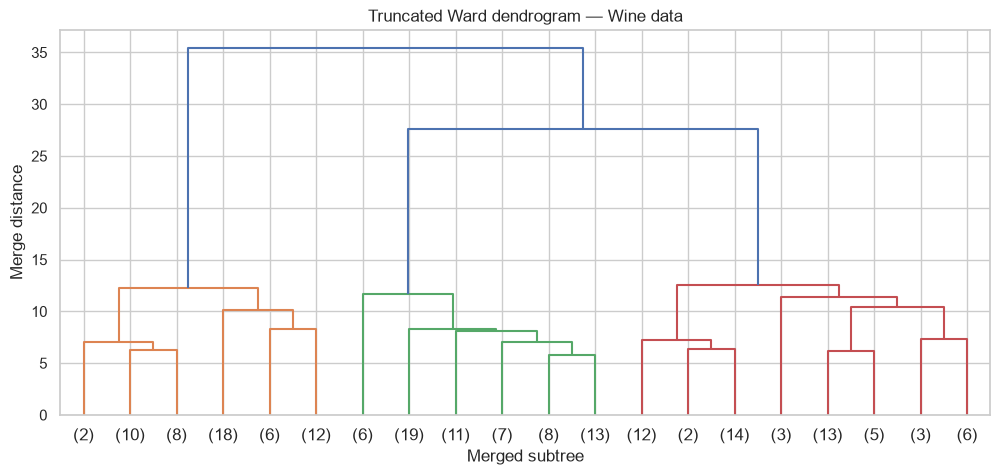

In [25]:
wine_scaler = StandardScaler()
X_wine_scaled = wine_scaler.fit_transform(wine_features)

wine_linkage = linkage(
    X_wine_scaled,
    method="ward",
)

plt.figure(figsize=(12, 5))
dendrogram(
    wine_linkage,
    truncate_mode="lastp",
    p=20,
    show_leaf_counts=True,
)
plt.title("Truncated Ward dendrogram — Wine data")
plt.xlabel("Merged subtree")
plt.ylabel("Merge distance")
plt.show()

### Activity 6 — Use the dendrogram as evidence

The dendrogram is truncated because 178 individual leaves would be difficult to read.

Answer:

1. Which candidate counts seem worth testing: 2, 3, 4, or more? - 3 clusters
2. What merge-height evidence supports your candidates? - large clean vertical gap after 3 clusters at around 13.0 - 27.5
3. What information is hidden by the truncation? - merges not visible on the graph

### Compare three candidate methods

To keep the comparison interpretable:

- K-means uses `k=3`,
- Ward agglomerative clustering uses `3` clusters,
- DBSCAN uses a candidate density setting.

The aim is not to force all methods to return the same structure.

In [26]:
WINE_K = 3
WINE_EPS = 2.30
WINE_MIN_SAMPLES = 3

wine_methods = {
    "K-means": KMeans(
        n_clusters=WINE_K,
        n_init=30,
        random_state=42,
    ).fit_predict(X_wine_scaled),

    "Agglomerative — Ward": AgglomerativeClustering(
        n_clusters=WINE_K,
        linkage="ward",
    ).fit_predict(X_wine_scaled),

    "DBSCAN": DBSCAN(
        eps=WINE_EPS,
        min_samples=WINE_MIN_SAMPLES,
    ).fit_predict(X_wine_scaled),
}

wine_summary_rows = []

for method_name, labels in wine_methods.items():
    wine_summary_rows.append({
        "method": method_name,
        "clusters": count_clusters(labels),
        "noise points": int((labels == -1).sum()),
        "silhouette": silhouette_without_noise(
            X_wine_scaled,
            labels,
        ),
    })

wine_summary = pd.DataFrame(wine_summary_rows)
wine_summary.round(3)

,method,clusters,noise points,silhouette
0,K-means,3,0,0.285
1,Agglomerative — Ward,3,0,0.277
2,DBSCAN,3,32,0.225


### Before revealing the cultivar

Choose the method you currently prefer for exploratory grouping.

Your initial recommendation:

> I prefer _____K-means_____ because _____it assigns every point to a group without discarding data_____.
>
> My evidence is _____highest silhouette score and 0 noise points_____.
>
> One concern is _____assumption that all clusters are spherical_____.

### Profile the Ward clusters in standardised units

A positive value means the cluster average is above the overall dataset mean.  
A negative value means it is below the mean.

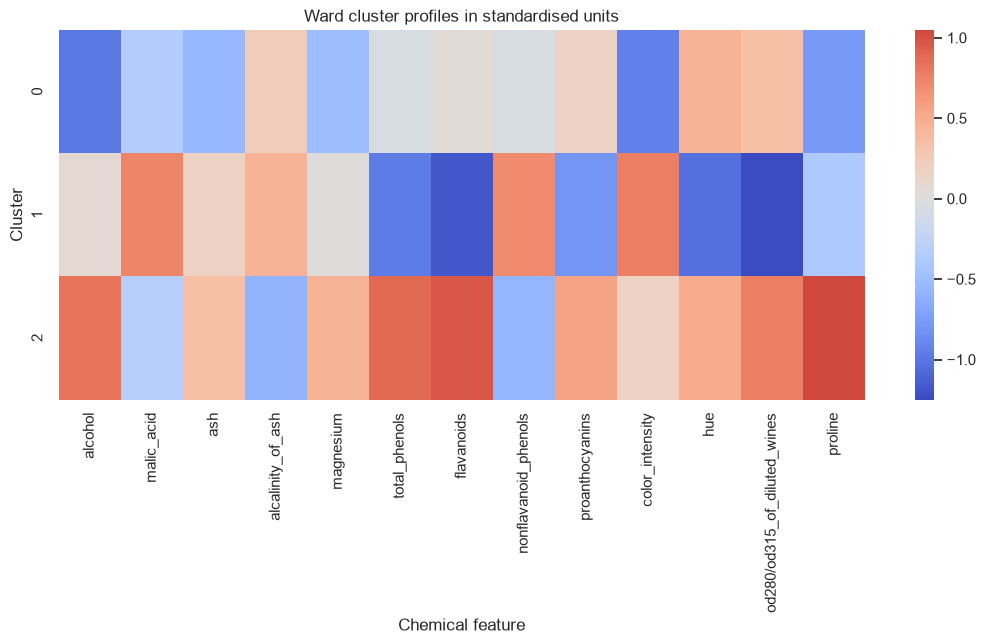

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
cluster,,,,,,,,,,,,,
0,-0.98,-0.36,-0.55,0.21,-0.50,-0.05,0.06,-0.05,0.17,-0.94,0.45,0.35,-0.78
1,0.08,0.75,0.17,0.45,0.01,-0.96,-1.19,0.71,-0.81,0.78,-1.04,-1.25,-0.39
2,0.83,-0.33,0.35,-0.59,0.45,0.89,0.98,-0.57,0.56,0.17,0.50,0.77,1.05


In [27]:
ward_labels = wine_methods["Agglomerative — Ward"]

wine_scaled_frame = pd.DataFrame(
    X_wine_scaled,
    columns=wine_features.columns,
)
wine_scaled_frame["cluster"] = ward_labels

ward_profile = wine_scaled_frame.groupby("cluster").mean()

plt.figure(figsize=(13, 4.8))
sns.heatmap(
    ward_profile,
    center=0,
    cmap="coolwarm",
    annot=False,
)
plt.title("Ward cluster profiles in standardised units")
plt.xlabel("Chemical feature")
plt.ylabel("Cluster")
plt.show()

ward_profile.round(2)

### Activity 7 — Interpret one real-data cluster

Choose one Ward cluster and write three sentences:

1. identify two or three features with strong deviations, proline +1.05, total_phenols +0.89, flavanoids +0.98
2. describe the cluster without inventing a causal story, This group represents a chemical profile defined by high concentrations of antioxidants, polyphenols, and alcohol, alongside lower-than-average alkalinity of ash
3. state one important within-cluster detail that the mean profile hides. - internal variance and distribution shape

**Your interpretation:**

Ward cluster 2 (64 wines) stands out with a high proline (+1.05 SD), high total phenols (+0.89 SD) and high flavanoids (+0.98 SD). It also has above-average alcohol (+0.83 SD) and below-average alcalinity of ash (−0.59 SD), so it describes a group of wines with a distinct chemical profile; this is a description of the measurements only, and I make no claim about why these wines differ. The mean profile hides the spread inside the cluster: proline has a within-cluster standard deviation of 0.83 SD (raw range about 410 to 1680), so some wines in this cluster are far from its average.

### Guided AI study activity — question your recommendation

Use AI only **after** writing your own recommendation and cluster interpretation.

Paste your draft and use this prompt:

```text
Act as a clustering tutor.
Do not rewrite my answer and do not tell me which method is best.
Ask me exactly three short questions, one at a time:

1. What numerical or visual evidence supports my choice?
2. Do the method's assumptions fit the cluster shape and noise in this dataset?
3. What limitation or alternative method should I mention?

Wait for my answer after each question.
```

Then close the chat and record only:

**One useful question from AI:**  Given that silhouette scores naturally favor compact, round shapes, do you think the actual clusters in this Wine dataset are spherical, or could K-means be forcing complex shapes into round blocks?

**One sentence I revised:**  I prefer K-means because it has the highest silhouette score of 0.285, assuming the chemical structures are naturally compact and spherical.

**Why the revised sentence is more accurate:**  The original thought only looked at the highest raw score, but the revision explicitly acknowledges that this preference relies on the geometric assumption that the clusters are spherical—meaning the choice would be invalid if the real data structures turned out to be complex or winding.

Do not paste the complete conversation.

### External audit: reveal the cultivar categories

The cultivar was not used during clustering. We now use it only to ask whether the partitions correspond to this known external grouping.

A high ARI is useful evidence for this particular external reference, but it does not automatically prove that the method is best for every analytical purpose.

In [28]:
wine_external_rows = []

for method_name, labels in wine_methods.items():
    wine_external_rows.append({
        "method": method_name,
        "ARI against cultivar": adjusted_rand_score(
            wine_reference,
            labels,
        ),
    })

wine_external = pd.DataFrame(wine_external_rows)
wine_external.round(3)

,method,ARI against cultivar
0,K-means,0.897
1,Agglomerative — Ward,0.790
2,DBSCAN,0.399


### Verification checkpoint

1. Did the external audit support or weaken your initial recommendation? - supported my K-means recommendation
2. Which conclusion should you revise? - I should not conclude that K-means is the best method in general, or that DBSCAN is a bad method. The audit only shows that, on this dataset and with these settings, K-means (ARI = 0.897) matched the cultivar grouping best, ahead of Ward (0.790) and DBSCAN (0.399). The DBSCAN result mostly reflects a poorly chosen density setting (32 noise points), and silhouette (0.285) is low in absolute terms, so the earlier “spherical clusters” assumption is supported here but not proven.
3. Why would it still be incorrect to say that the cultivar labels are the only possible “true” clustering? - the cultivar is only one external reference. The same wines could be grouped sensibly by other criteria (for example colour intensity or alcohol level), and the 13 chemical features may contain structure that does not line up with the cultivar. A low ARI would therefore show disagreement with this one label, not that the clustering is wrong.

## 7. Assessed task — Method-selection memo (2 points)

You are preparing a short recommendation for a colleague who wants exploratory groups in the Wine data.

Use the prepared results and perform **one additional comparison**:

- change `WINE_EPS` to one other defensible value, **or**
- change the agglomerative linkage, **or**
- test one additional cluster count suggested by the dendrogram.

Submit a concise memo containing:

1. **Question:** What grouping decision are you evaluating?
2. **Methods compared:** At least two methods or parameter settings.
3. **Evidence:** One visual and one numerical result.
4. **Recommendation:** A method and parameters.
5. **Cluster interpretation:** A short evidence-based description of one cluster.
6. **Limitation:** One reason the recommendation may not transfer to another dataset or purpose.
7. **AI note:** If AI was used, state one question it asked and one claim you independently verified.

### Marking

| Criterion | Points |
|---|---:|
| Comparison and evidence are technically appropriate | 0.75 |
| Recommendation follows from the evidence | 0.50 |
| Cluster interpretation is cautious and specific | 0.50 |
| Limitation or verified AI note is meaningful | 0.25 |

In [33]:
# Change ONE clearly marked setting and rerun the comparison.

ALTERNATIVE_EPS = 2.50
ALTERNATIVE_LINKAGE = "complete"
ALTERNATIVE_K = 4

# Option A: alternative DBSCAN
alternative_dbscan = DBSCAN(
    eps=ALTERNATIVE_EPS,
    min_samples=WINE_MIN_SAMPLES,
).fit_predict(X_wine_scaled)

# Option B: alternative agglomerative linkage
alternative_agglomerative = AgglomerativeClustering(
    n_clusters=ALTERNATIVE_K,
    linkage=ALTERNATIVE_LINKAGE,
).fit_predict(X_wine_scaled)

additional_comparison = pd.DataFrame([
    {
        "setting": f"DBSCAN eps={ALTERNATIVE_EPS}",
        "clusters": count_clusters(alternative_dbscan),
        "noise points": int((alternative_dbscan == -1).sum()),
        "silhouette": silhouette_without_noise(
            X_wine_scaled,
            alternative_dbscan,
        ),
        "ARI against cultivar": adjusted_rand_score(
            wine_reference,
            alternative_dbscan,
        ),
    },
    {
        "setting": (
            f"Agglomerative {ALTERNATIVE_LINKAGE}, "
            f"k={ALTERNATIVE_K}"
        ),
        "clusters": count_clusters(alternative_agglomerative),
        "noise points": int((alternative_agglomerative == -1).sum()),
        "silhouette": silhouette_without_noise(
            X_wine_scaled,
            alternative_agglomerative,
        ),
        "ARI against cultivar": adjusted_rand_score(
            wine_reference,
            alternative_agglomerative,
        ),
    },
])

additional_comparison.round(3)

,setting,clusters,noise points,silhouette,ARI against cultivar
0,DBSCAN eps=2.5,1,23,NaN,0.008
1,"Agglomerative complete, k=4",4,0,0.194,0.643


# Your method-selection memo

**Question:**  
What clustering algorithm, linkage type, and cluster count (k) optimize the extraction of meaningful, real-world exploratory groupings from the standardized Wine chemical measurement dataset?

**Methods and settings compared:**  
Baseline models (k=3): K-means, Agglomerative Clustering (Ward linkage), and baseline DBSCAN.
Alternative models: DBSCAN with an expanded radius (eps=2.50) and Agglomerative Clustering with a different geometry and cluster count (Complete linkage, k=4).

**Visual evidence:**  
The truncated Ward dendrogram reveals a prominent, stable vertical gap between a merge distance of approximately 13.0 and 27.5, which strongly supports partitioning the wine samples into exactly 3 clusters. Slicing the data into 4 clusters via complete linkage is not supported by the Ward dendrogram, whose gap favours 3 clusters, and it lowers both silhouette (0.194 vs 0.285) and ARI (0.643 vs 0.897).

**Numerical evidence:**  
K-means (k=3) yielded the highest structure optimization with a Silhouette score of 0.285 and 0 noise points. The external audit supported this choice, with the highest ARI of 0.897 against the cultivar labels (Ward 0.790, DBSCAN 0.399). 
By comparison, the alternative configurations performed poorly: increasing DBSCAN's radius to eps=2.5 caused the data to collapse into a single cluster plus 23 noise points (ARI = 0.008)
Agglomerative Complete linkage (\(k=4\)) caused the performance to drop significantly (Silhouette = 0.194, ARI = 0.643).

**Recommendation:**  
I recommend using K-means with \(k=3\) on the standardized features.

**Interpretation of one cluster:**  
K-means cluster 2 (62 wines) has above-average proline (+1.13 SD), flavanoids (+0.98 SD), total phenols (+0.89 SD) and alcohol (+0.84 SD), and below-average alcalinity of ash (−0.61 SD). This describes the measured chemical profile only and does not explain why the wines differ. The mean hides considerable spread: proline varies within the cluster (SD about 0.74 in standardised units), so not every wine in it is a high-proline wine.

**Limitation:**  
K-means needs k chosen in advance and assumes compact, roughly spherical clusters of similar size. The silhouette score of 0.285 is modest, so the groups overlap, and the good result (ARI 0.897) is specific to this dataset and to the cultivar as reference. On data with curved or irregular clusters, or with outliers, K-means would likely fail (as on the moons and circles) and DBSCAN or single-linkage clustering could be better; DBSCAN here was also sensitive to `eps` (32 noise points at 2.3, one cluster at 2.5).

**Optional verified AI note:**  
The AI tutor asked whether the Wine clusters are really spherical or whether K-means might be forcing complex shapes into round blocks. I checked this independently: K-means with k=3 gave ARI = 0.897 against the cultivar labels, and the Ward hierarchy (ARI = 0.790) gave a similar grouping (K-means vs Ward agreement ARI = 0.85), which suggests the structure is reasonably compact, though the low silhouette (0.285) means the groups are not sharply separated.

# End-of-lab self-check

Before finishing, check that you can:

- [x] explain how agglomerative clustering builds a hierarchy,
- [x] read merge height on a dendrogram,
- [x] explain what changes when a dendrogram cut moves,
- [x] distinguish single, complete, and Ward linkage,
- [x] explain `eps` and `min_samples`,
- [x] distinguish core, border, and noise points,
- [x] identify fragmentation and merging in DBSCAN,
- [x] explain why silhouette alone may be misleading,
- [x] recommend a method based on geometry, density, noise, and evidence,
- [x] revise an interpretation after questions without copying an AI answer.

Exercise 5 will move from unsupervised learning to optimisation and linear models.